In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/processed/landlord/feature_data.csv")

In [4]:
data['session'].nunique()

44

Number of invocations per sessions - some stats

In [5]:
data[['session', 'tid']].groupby('session').count().min(), data[['session', 'tid']].groupby('session').count().max(), data[['session', 'tid']].groupby('session').count().mean()

(tid    818
 dtype: int64,
 tid    3052
 dtype: int64,
 tid    1784.863636
 dtype: float64)

E2E time distribution

avg e2e times 1.16 seconds


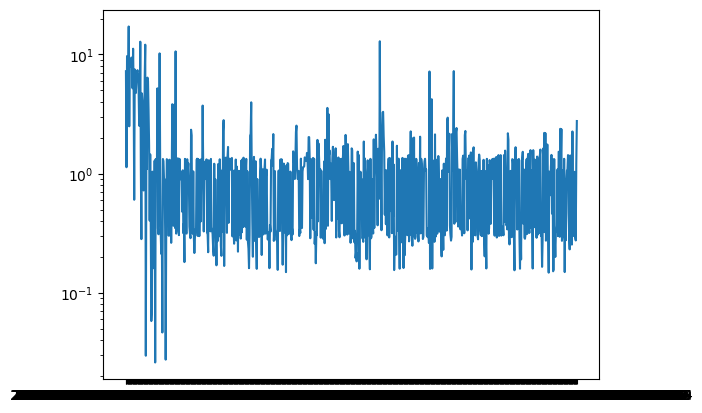

In [10]:
session = 'session_112_12'
session_data = data[data['session'] == session].sort_values(by='invocation_timestamp').reset_index(drop=True)
print(f"avg e2e times {round(session_data['e2etime'].mean(), 3)} seconds")
plt.figure()
plt.plot(session_data['invocation_timestamp'].values, session_data['e2etime'].values)
plt.yscale('log')  # Latency is best viewed on a log scale
plt.show()

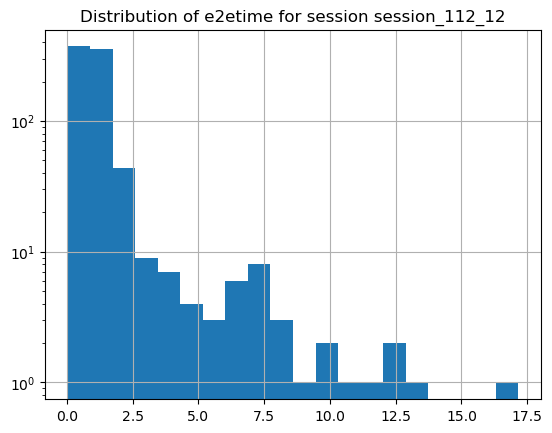

In [11]:
plt.figure()
session_data['e2etime'].hist(bins=20)
plt.title(f"Distribution of e2etime for session {session}")
plt.yscale('log')
plt.show()

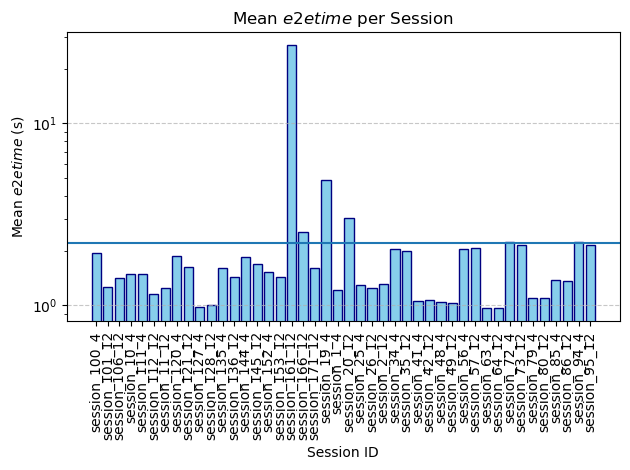

In [12]:
def get_session_stats(df, session_col='session', value_col='e2etime'):
    """
    Calculates the mean value per session and ensures the data is sorted.
    """
    # Group by session and calculate mean
    stats = df.groupby(session_col)[value_col].mean().reset_index()
    
    # Sort by session id to ensure a logical order on the x-axis
    stats = stats.sort_values(session_col)
    return stats

def plot_mean_latency(stats, session_col='session', value_col='e2etime', save_path='session_latency(log).png'):
    """
    Creates a bar plot for mean latency per session.
    """
    # 1. Setup plot labels and aesthetics
    # Convert session IDs to strings for categorical-style x-axis spacing
    x_labels = stats[session_col].astype(str)
    y_values = stats[value_col]

    plt.bar(x_labels, y_values, color='skyblue', edgecolor='navy')
    
    # 2. Formatting
    plt.title('Mean $e2etime$ per Session')
    plt.xlabel('Session ID')
    plt.ylabel('Mean $e2etime$ (s)')
    plt.yscale('log')
    plt.axhline(y_values.mean())
    # Rotate labels if you have many sessions
    plt.xticks(rotation=90)
    
    # Add a grid for easier reading of values
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 3. Finalize
    plt.tight_layout()

session_stats = get_session_stats(data)
plot_mean_latency(session_stats)

Effect of fqdn on e2e time - Does fqdn affect?

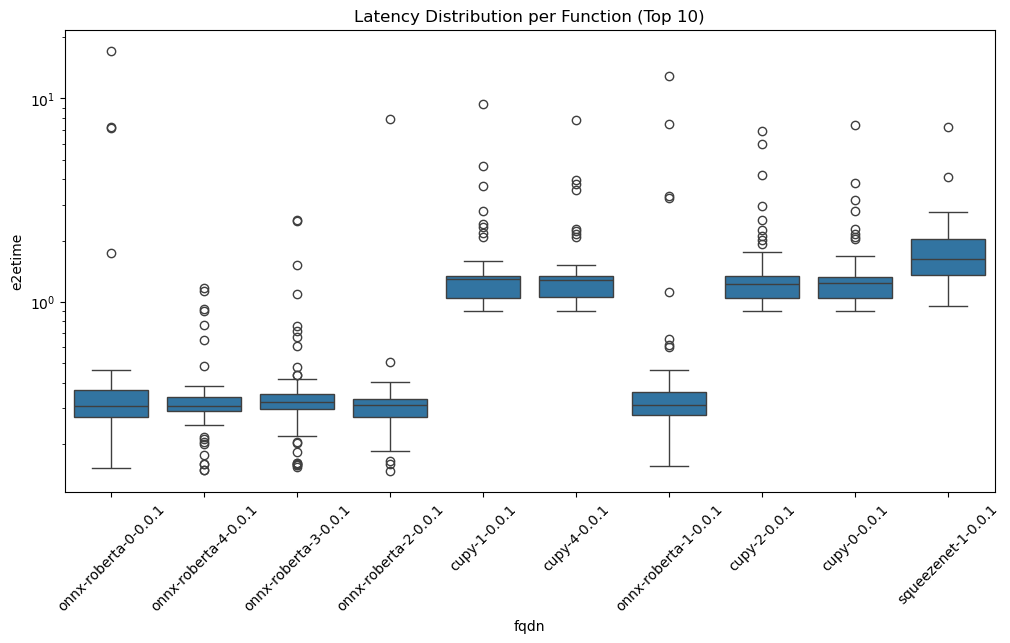

In [13]:
top_functions = session_data['fqdn'].value_counts().nlargest(10).index
subset = session_data[session_data['fqdn'].isin(top_functions)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='fqdn', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per Function (Top 10)")
plt.show()

GPU representation - Looking at two features here:
1. `num_running_funcs_filled` - Effect of number of functions running currently on e2etime
2. `is_cold_start` - a binary flag that indicate whether the execution is going to be a cold start or not

Number of functions running currently at the time of invocation

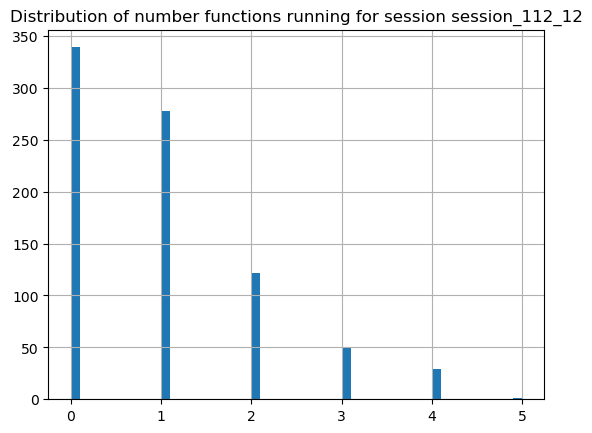

In [14]:
plt.figure()
session_data['num_running_funcs_filled'].hist(bins=50)
plt.title(f"Distribution of number functions running for session {session}")
plt.show()

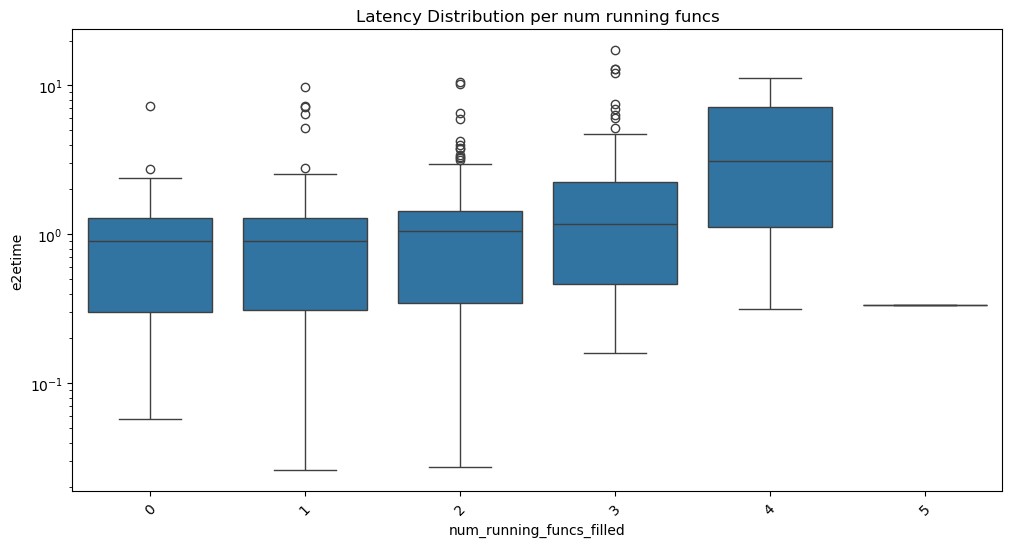

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=session_data, x='num_running_funcs_filled', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution per num running funcs")
plt.show()

is_cold_start

In [16]:
session_data['is_cold_start'].value_counts()

is_cold_start
0    791
1     27
Name: count, dtype: int64

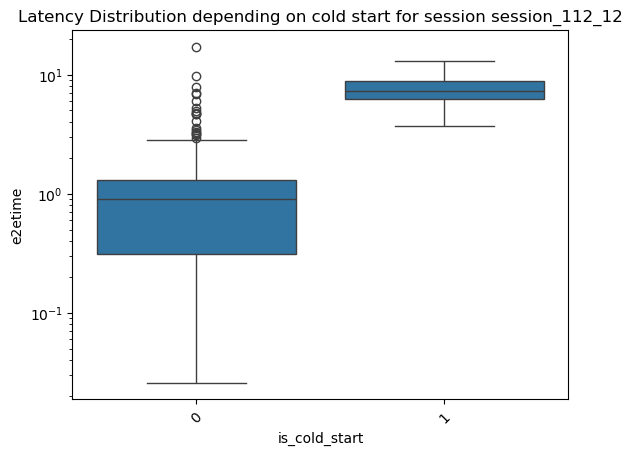

In [17]:
plt.figure()
sns.boxplot(data=session_data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title(f"Latency Distribution depending on cold start for session {session}")
plt.show()

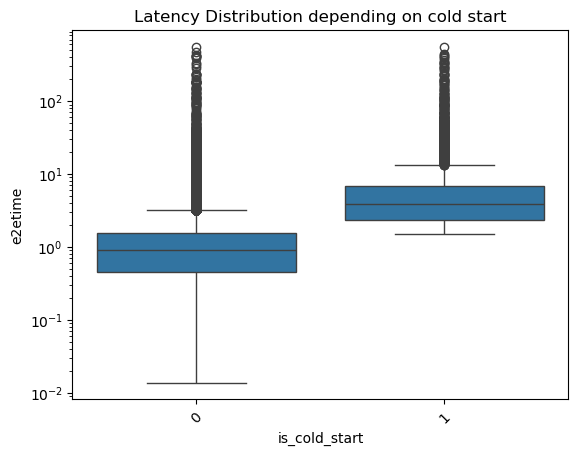

In [18]:
plt.figure()
sns.boxplot(data=data, x='is_cold_start', y='e2etime')
plt.yscale('log')  # Latency is best viewed on a log scale
plt.xticks(rotation=45)
plt.title("Latency Distribution depending on cold start")
plt.show()

Queue length stats - Here, we look at 2 features
1. `target_queue_len` - queue length of the incoming fqdn
2. `others_len_queue` - sum of queue lengths of all fqdn queue lengths except the incoming fqdn

In [19]:
data['target_queue_len'].value_counts()

target_queue_len
0.0     76885
1.0      1505
2.0        53
3.0        22
5.0        22
4.0        15
6.0        13
9.0         6
8.0         6
7.0         4
10.0        2
13.0        1
Name: count, dtype: int64

In [20]:
data['others_len_queue'].value_counts()

others_len_queue
0.0     59153
1.0      9662
2.0      3673
3.0      1895
4.0      1135
        ...  
89.0        1
88.0        1
81.0        1
77.0        1
83.0        1
Name: count, Length: 84, dtype: int64

Correlation between `target_queue_len` and `e2etime`

In [21]:
(session_data['target_queue_len']).corr(session_data['e2etime']), (data['target_queue_len']).corr(data['e2etime']) 

(0.16010944196468677, 0.6462450058998566)

In [22]:
(session_data['others_len_queue']).corr(session_data['e2etime']), (data['others_len_queue']).corr(data['e2etime']) 

(0.4737910339388115, 0.42829534879769043)

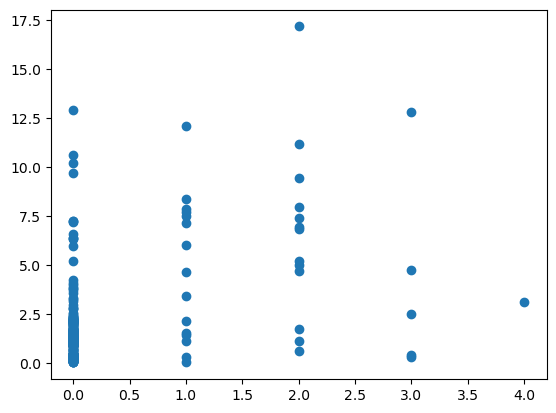

In [23]:
plt.figure()
plt.scatter(session_data['others_len_queue'], session_data['e2etime'])
plt.show()

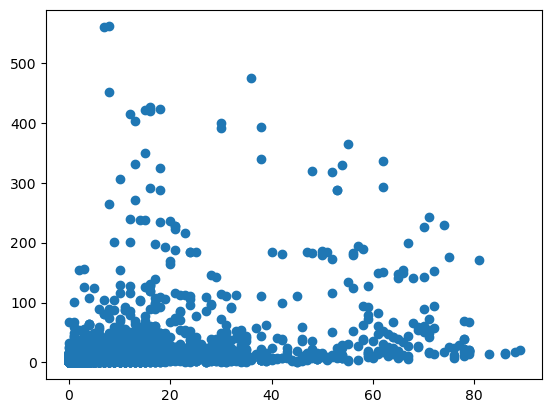

In [24]:
plt.figure()
plt.scatter(data['others_len_queue'], data['e2etime'])
plt.show()

In [25]:
base_cols = [
            'target_queue_len', 'others_len_queue', 'iat_fqdn', 'num_running_funcs_filled',
            'gpu_warm_results_sec', 'gpu_cold_results_sec', 'is_cold_start'
        ]
data[base_cols+['e2etime']].corr()

,target_queue_len,others_len_queue,iat_fqdn,num_running_funcs_filled,gpu_warm_results_sec,gpu_cold_results_sec,is_cold_start,e2etime
target_queue_len,1.000000,0.358724,-0.003463,0.263236,0.007583,-0.002571,0.041848,0.646245
others_len_queue,0.358724,1.000000,0.006720,0.594201,-0.027172,0.001153,0.096476,0.428295
iat_fqdn,-0.003463,0.006720,1.000000,0.013289,-0.008886,0.021899,0.062396,0.014570
num_running_funcs_filled,0.263236,0.594201,0.013289,1.000000,-0.063465,0.029511,0.122919,0.329230
gpu_warm_results_sec,0.007583,-0.027172,-0.008886,-0.063465,1.000000,0.062311,-0.029975,0.031529
gpu_cold_results_sec,-0.002571,0.001153,0.021899,0.029511,0.062311,1.000000,0.100487,0.081047
is_cold_start,0.041848,0.096476,0.062396,0.122919,-0.029975,0.100487,1.000000,0.186919
e2etime,0.646245,0.428295,0.014570,0.329230,0.031529,0.081047,0.186919,1.000000
